# Practice Project: Titanic Survival Prediction

# Introduction

Now that you have a feel for how to optimize your machine learning pipeline, let's practice with a real world dataset.
You'll use cross validation and a hyperparameter grid search to optimize your machine learning pipeline.

You will use the Titanic Survival Dataset to build a classification model to predict whether a passenger survived the sinking of the Titanic, based on attributes of each passenger in the data set.

You'll start with building a Random Forest Classifier, then modify your pipeline to use a Logistic Regression estimator instead. You'll evaluate and compare your results.

This lab will help prepare you for completing the Final Project.

# Objectives

After completing this lab you will be able to:

- Use scikit-learn to build a model to solve a classification problem
- Implement a pipeline to combine your preprocessing steps with a machine learning model
- Interpret the results of your modelling
- Update your pipeline with a different machine learning model
- Compare the preformances of your classifiers

In [1]:
# Install the required libraries

!pip install numpy
!pip install matplotlib
!pip install pandas
!pip install scikit-learn
!pip install seaborn

In [3]:
# Import the required libraries¶

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.decomposition import PCA
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline
import seaborn as sns
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

In [4]:
# Load the Titanic dataset using Seaborn => Data is loaded into a dataframe

titanic = sns.load_dataset('titanic')
titanic.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [9]:
# Number of values in ecah column

titanic.count()

survived       891
pclass         891
sex            891
age            714
sibsp          891
parch          891
fare           891
embarked       889
class          891
who            891
adult_male     891
deck           203
embark_town    889
alive          891
alone          891
dtype: int64

In [10]:
# Check the columns and their dtypes

titanic.dtypes

survived          int64
pclass            int64
sex              object
age             float64
sibsp             int64
parch             int64
fare            float64
embarked         object
class          category
who              object
adult_male         bool
deck           category
embark_town      object
alive            object
alone              bool
dtype: object

# Features to drop

deck has a lot of missing values so we'll drop it. age has quite a few missing values as well. Although it could be, embarked and embark_town don't seem relevant so we'll drop them as well. It's unclear what alive refers to so we'll ignore it.

# Target

survived is our target class variable.

In [13]:
# Define the features and the target => features is here a list

features = ['pclass', 'sex', 'age', 'sibsp', 'parch', 'fare', 'class', 'who', 'adult_male', 'alone']
target = 'survived'

# X and y are parts of the titanic dataframe => they are also dataframes

X = titanic[features]
y = titanic[target]

In [14]:
# Check the first 5 rows of X

X.head()

,pclass,sex,age,sibsp,parch,fare,class,who,adult_male,alone
0,3,male,22.0,1,0,7.2500,Third,man,True,False
1,1,female,38.0,1,0,71.2833,First,woman,False,False
2,3,female,26.0,0,0,7.9250,Third,woman,False,True
3,1,female,35.0,1,0,53.1000,First,woman,False,False
4,3,male,35.0,0,0,8.0500,Third,man,True,True


In [15]:
# Check the first 5 rows of y

y.head()

0    0
1    1
2    1
3    1
4    0
Name: survived, dtype: int64

# Exercise 1. How balanced are the classes? => counts per each value 'survived'/'not survived'

In [16]:
y.value_counts()

# So, about 38% of the passengers in the data set survived.  
# Because of this slight imbalance, we should stratify the data when performing train/test split and for cross-validation.

survived
0    549
1    342
Name: count, dtype: int64

# Exercise 2. Split the data into training and testing sets

Don't forget to consider imbalance in the target => need to stratify the chosen training and testing groups

In [17]:
# Split the dataset in a training and a testing group

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Define preprocessing transformers for numerical and categorical features¶

In [20]:
# Automatically detect numerical and categorical columns and assign them to separate numeric and categorical features

numerical_features = X_train.select_dtypes(include=['number']).columns.tolist()
categorical_features = X_train.select_dtypes(include=['object', 'category']).columns.tolist()

In [21]:
# Define separate preprocessing pipelines for both feature types¶

numerical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

# Combine the transformers into a single column transformer

We'll use the sklearn "column transformer" estimator to separately transform the features, which will then concatenate the output as a single feature space, ready for input to a machine learning estimator.

In [22]:
# Use of "column transformer" estimator to separately transform the features, 
# which will then concatenate the output as a single feature space, ready for input to a machine learning estimator.

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numerical_transformer, numerical_features),
        ('cat', categorical_transformer, categorical_features)
    ])

# Create a model pipeline

Now let's complete the model pipeline by combining the preprocessing with a Random Forest classifier.

In [23]:
# Definition oa pipeline combining the preprocessing with a Random Forest Classifier

pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(random_state=42))
])

# Define a parameter grid

We'll use the grid in a cross validation search to optimize the model

In [24]:
# Definition of a parameter grid that will be used in the cross validation model to search to optimize the model

param_grid = {
    'classifier__n_estimators': [50, 100],
    'classifier__max_depth': [None, 10, 20],
    'classifier__min_samples_split': [2, 5]
}

# Perform grid search cross-validation and fit the best model to the training data¶

In [25]:
# Definition of the Cross-validation method

cv = StratifiedKFold(n_splits=5, shuffle=True)

# Exercise 3. Train the pipeline model

# Train the pipeline model using the training data

model = GridSearchCV(estimator=pipeline, param_grid=param_grid, cv=cv, scoring='accuracy', verbose=2)
model.fit(X_train, y_train)

# Exercise 4. Get the model predictions from the grid search estimator on the unseen data

In [27]:
# Get a predictionmodel using the testing data

y_pred = model.predict(X_test)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.82      0.88      0.85       110
           1       0.79      0.70      0.74        69

    accuracy                           0.81       179
   macro avg       0.80      0.79      0.79       179
weighted avg       0.81      0.81      0.81       179



# Exercise 5. Plot the confusion matrix¶

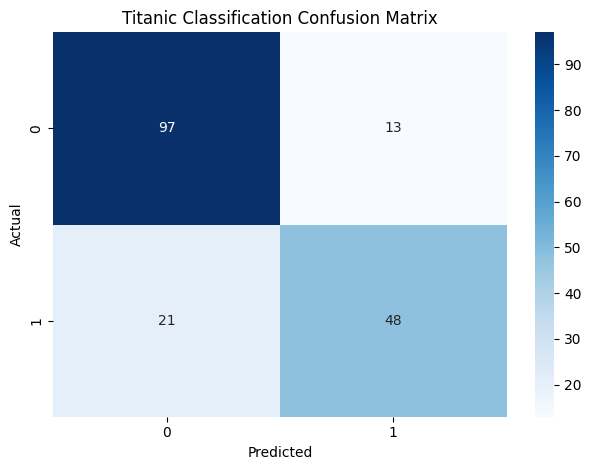

In [28]:
# Generate the confusion matrix 
conf_matrix = confusion_matrix(y_test, y_pred)

plt.figure()
sns.heatmap(conf_matrix, annot=True, cmap='Blues', fmt='d')

# Set the title and labels
plt.title('Titanic Classification Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')

# Show the plot
plt.tight_layout()
plt.show()

# Feature importances

Let's figure out how to get the feature importances of our overall model. You'll need to know how to do this for your final project.
First, to obtain the categorical feature importances, we have to work our way backward through the modelling pipeline to associate the feature importances with their one-hot encoded input features that were transformed from the original categorical features.

We don't need to trace back through the pipeline for the numerical features, because we didn't transfrom them into new ones in any way.
Remember, we went from categorical features to one-hot encoded features, using the 'cat' column transformer.

Here's how you trace back through the trained model to access the one-hot encoded feature names:

In [29]:
# Trace back through the trained model to access the one-hot encoded feature names => we want to check the feature 
# importances associated with their one-hot encoded input features (that were transformed from the original categorical features)

model.best_estimator_['preprocessor'].named_transformers_['cat'].named_steps['onehot'].get_feature_names_out(categorical_features)

array(['sex_female', 'sex_male', 'class_First', 'class_Second',
       'class_Third', 'who_child', 'who_man', 'who_woman'], dtype=object)

# Notice how the one-hot encoded features are named - for example, sex was split into two boolean features indicating whether the sex is male or female.

Great! Now let's get all of the feature importances and associate them with their transformed feature names.

In [30]:
# Definition of the feature importances and association with their transformed feature names

feature_importances = model.best_estimator_['classifier'].feature_importances_

# Combine the numerical and one-hot encoded categorical feature names

feature_names = numerical_features + list(model.best_estimator_['preprocessor']
                                        .named_transformers_['cat']
                                        .named_steps['onehot']
                                        .get_feature_names_out(categorical_features))

In [32]:
print(feature_names)

['pclass', 'age', 'sibsp', 'parch', 'fare', 'sex_female', 'sex_male', 'class_First', 'class_Second', 'class_Third', 'who_child', 'who_man', 'who_woman']


# Display the feature importances in a bar plot

Define a feature importance DataFrame, then plot it

In [33]:
# Definition of a feature importance dataframe

importance_df = pd.DataFrame({'Feature': feature_names,
                              'Importance': feature_importances
                             }).sort_values(by='Importance', ascending=False)

importance_df

,Feature,Importance
4,fare,0.211146
1,age,0.169984
6,sex_male,0.133274
11,who_man,0.107059
5,sex_female,0.102591
12,who_woman,0.053158
2,sibsp,0.049358
0,pclass,0.045401
9,class_Third,0.040621
3,parch,0.034298


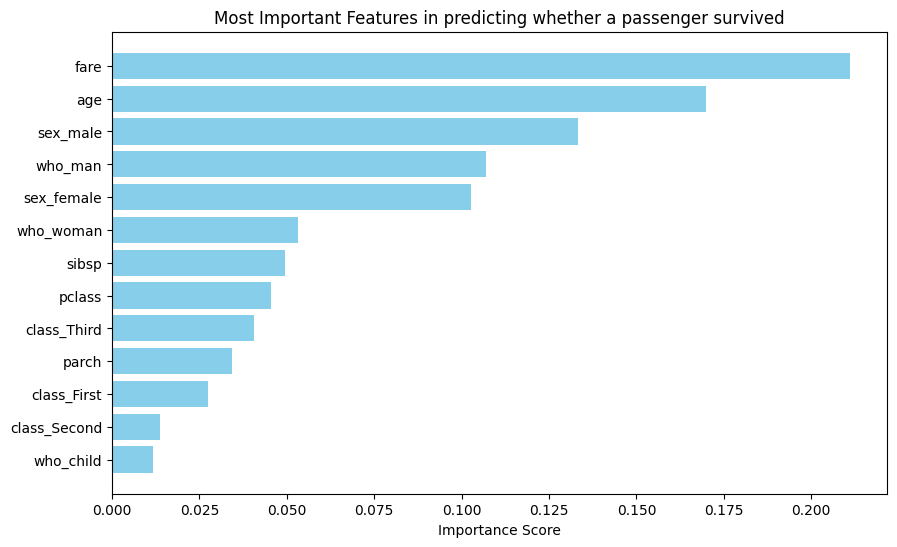

In [34]:
# Bar plot of the feature vs. importance score

plt.figure(figsize=(10, 6))
plt.barh(importance_df['Feature'], importance_df['Importance'], color='skyblue')
plt.gca().invert_yaxis() 
plt.title('Most Important Features in predicting whether a passenger survived')
plt.xlabel('Importance Score')
plt.show()

In [35]:
# Print test score 

test_score = model.score(X_test, y_test)
print(f"\nTest set accuracy: {test_score:.2%}")


Test set accuracy: 81.01%


# Exercise 6. These are interesting results to consider.

What can you say about these feature importances? Are they informative as is?

The test set accuracy is somewhat satisfactory. However,regarding the feature impoirtances, it's crucially important to realize that there is most likely plenty of dependence amongst these variables, and a more detailed modelling approach including correlation analysis is required to draw proper conclusions. For example, no doubt there is significant information shared by the variables `age`, `sex_male`, and `who_man`.

# Try another model

In practice you would want to try out different models and even revisit the data analysis to improve your model performance. Maybe you can engineer new features or impute missing values to be able to use more data.

With Scikit-learn's powerful pipeline class, this is easy to do in a few steps. Let's update the pipeline and the parameter grid so we can train a Logistic Regression model and compare the performance of the two models.

In [36]:
# Replace RandomForestClassifier with LogisticRegression

pipeline.set_params(classifier=LogisticRegression(random_state=42))

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['pclass', 'age', 'sibsp',
                                                   'parch', 'fare']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['sex', 'class', 'who'])])),
                ('classifier', LogisticRegression(random_state=42))])

In [37]:
# update the model's estimator to use the new pipeline

model.estimator = pipeline


In [38]:
# Define a new grid with Logistic Regression parameters

param_grid = {
    # 'classifier__n_estimators': [50, 100],
    # 'classifier__max_depth': [None, 10, 20],
    # 'classifier__min_samples_split': [2, 5],
    'classifier__solver' : ['liblinear'],
    'classifier__penalty': ['l1', 'l2'],
    'classifier__class_weight' : [None, 'balanced']
}

model.param_grid = param_grid

In [39]:
# Fit the updated pipeline with Logistic Regression

model.fit(X_train, y_train)

Fitting 5 folds for each of 4 candidates, totalling 20 fits
[CV] END classifier__class_weight=None, classifier__penalty=l1, classifier__solver=liblinear; total time=   0.0s
[CV] END classifier__class_weight=None, classifier__penalty=l1, classifier__solver=liblinear; total time=   0.0s
[CV] END classifier__class_weight=None, classifier__penalty=l1, classifier__solver=liblinear; total time=   0.0s
[CV] END classifier__class_weight=None, classifier__penalty=l1, classifier__solver=liblinear; total time=   0.0s
[CV] END classifier__class_weight=None, classifier__penalty=l1, classifier__solver=liblinear; total time=   0.0s
[CV] END classifier__class_weight=None, classifier__penalty=l2, classifier__solver=liblinear; total time=   0.0s
[CV] END classifier__class_weight=None, classifier__penalty=l2, classifier__solver=liblinear; total time=   0.0s
[CV] END classifier__class_weight=None, classifier__penalty=l2, classifier__solver=liblinear; total time=   0.0s
[CV] END classifier__class_weight=No

/opt/anaconda3/lib/python3.13/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/opt/anaconda3/lib/python3.13/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/opt/anaconda3/lib/python3.13/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/opt/anaconda3/lib/python3.13/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/opt/anaconda3/lib/python3.13/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/opt/anaconda3/lib/python3.13/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/opt/anaconda3/lib/python3.13/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/opt/anaconda3/lib/python3.

GridSearchCV(cv=StratifiedKFold(n_splits=5, random_state=None, shuffle=True),
             estimator=Pipeline(steps=[('preprocessor',
                                        ColumnTransformer(transformers=[('num',
                                                                         Pipeline(steps=[('imputer',
                                                                                          SimpleImputer(strategy='median')),
                                                                                         ('scaler',
                                                                                          StandardScaler())]),
                                                                         ['pclass',
                                                                          'age',
                                                                          'sibsp',
                                                                          'parch',
                                                                          'fare']),
                                                                        ('cat',
                                                                         Pipeline(steps=[('imputer',
                                                                                          SimpleImputer(strategy='most_frequent')),
                                                                                         ('onehot',
                                                                                          OneHotEncoder(handle_unknown='ignore'))]),
                                                                         ['sex',
                                                                          'class',
                                                                          'who'])])),
                                       ('classifier',
                                        LogisticRegression(random_state=42))]),
             param_grid={'classifier__class_weight': [None, 'balanced'],
                         'classifier__penalty': ['l1', 'l2'],
                         'classifier__solver': ['liblinear']},
             scoring='accuracy', verbose=2)

In [40]:
# Make predictions using this new pipeline (with Logistic Regression)

y_pred = model.predict(X_test)

/opt/anaconda3/lib/python3.13/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/opt/anaconda3/lib/python3.13/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/opt/anaconda3/lib/python3.13/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b


# Exercise 7. Display the clasification report for the new model and compare the results to your previous model.

In [41]:
# Get a predictionmodel using the testing data

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.84      0.89      0.86       110
           1       0.81      0.72      0.76        69

    accuracy                           0.83       179
   macro avg       0.82      0.81      0.81       179
weighted avg       0.83      0.83      0.82       179



# All of the scores are slightly better for logistic regression than for random forest classification, although the differences are insignificant.

# Exercise 8. Display the confusion matrix for the new model and compare the results to your previous model.¶

# Generate the confusion matrix 

conf_matrix = confusion_matrix(y_test, y_pred)

plt.figure()
sns.heatmap(conf_matrix, annot=True, cmap='Reds', fmt='d')

# Set the title and labels

plt.title('Titanic Classification Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')

# Show the plot

plt.tight_layout()
plt.show()

# Again, the results show a slight improvement, with one more true positive and one more true negative.

In [ ]:
Extract the logistic regression feature coefficients and plot their magnitude in a bar chart.¶

In [43]:
# Extraction of the logistic regression feature coefficients

coefficients = model.best_estimator_.named_steps['classifier'].coef_[0]
coefficients

array([-0.84964419, -0.29094786, -0.43418819, -0.18239881,  0.15616744,
        0.44826836,  0.        ,  0.03749489,  0.        ,  0.        ,
        0.68919246, -1.89029477,  0.7307953 ])

In [46]:
# Combine numerical and categorical feature names

numerical_feature_names = numerical_features
categorical_feature_names = (model.best_estimator_.named_steps['preprocessor']
                                     .named_transformers_['cat']
                                     .named_steps['onehot']
                                     .get_feature_names_out(categorical_features)
                            )
feature_names = numerical_feature_names + list(categorical_feature_names)
print(feature_names)

['pclass', 'age', 'sibsp', 'parch', 'fare', 'sex_female', 'sex_male', 'class_First', 'class_Second', 'class_Third', 'who_child', 'who_man', 'who_woman']


# Exercise 9. Plot the feature coefficient magnitudes in a bar chart

What's different about this chart than the feature importance chart for the Random Forest classifier?

In [47]:
# Creation of a dataframe for the feature coefficients

importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Coefficient': coefficients
}).sort_values(by='Coefficient', ascending=False, key=abs)  # Sort by absolute values

importance_df

,Feature,Coefficient
11,who_man,-1.890295
0,pclass,-0.849644
12,who_woman,0.730795
10,who_child,0.689192
5,sex_female,0.448268
2,sibsp,-0.434188
1,age,-0.290948
3,parch,-0.182399
4,fare,0.156167
7,class_First,0.037495


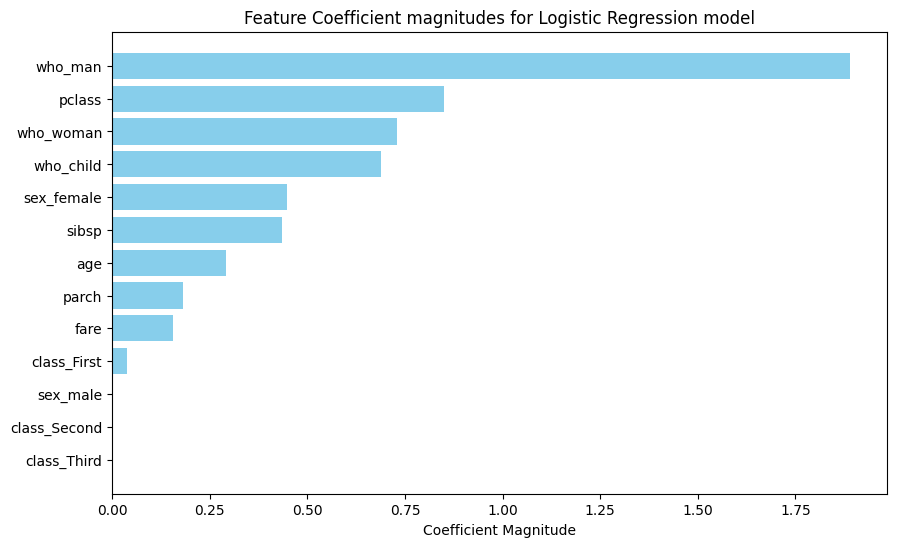

In [48]:
# Plotting of the feature coefficients

plt.figure(figsize=(10, 6))
plt.barh(importance_df['Feature'], importance_df['Coefficient'].abs(), color='skyblue')
plt.gca().invert_yaxis()
plt.title('Feature Coefficient magnitudes for Logistic Regression model')
plt.xlabel('Coefficient Magnitude')
plt.show()

In [49]:
# Print test score

test_score = model.best_estimator_.score(X_test, y_test)
print(f"\nTest set accuracy: {test_score:.2%}")


Test set accuracy: 82.68%


/opt/anaconda3/lib/python3.13/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/opt/anaconda3/lib/python3.13/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/opt/anaconda3/lib/python3.13/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b


# Although the performances of the two models are virtually identical, the features that are important to the two models are very different. This suggests there must be more work to do to better grasp the actual feature importances. As mentioned above, it's crucially important to realize that there is most likely plenty of dependence amongst these variables, and a more detailed modelling approach including correlation analysis is required to draw proper conclusions. For example, there significant information implied between the variables who_man, who_woman, and who_child, because if a person is neither a man nor a woman, then they must be a child.